In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Junayed\pandas_prac\Aug_20\messy_bizdirectory.csv")
df.shape

(35, 12)

In [3]:
df.dtypes

BusinessID             str
BusinessName           str
Category               str
City                   str
Email                  str
Website                str
YearsInBusiness        str
Rating             float64
NumEmployees       float64
SignupDate             str
Newsletter             str
Notes              float64
dtype: object

In [4]:
df.head(3)

,BusinessID,BusinessName,Category,City,Email,Website,YearsInBusiness,Rating,NumEmployees,SignupDate,Newsletter,Notes
0,B001,Bright Leaf Salon,Salon,Denver,contact@brightleaf.com,https://www.brightleaf.com,13,4.4,6.0,2023-09-04,No,NaN
1,B002,Blue Oak Consulting,Consulting,Austin,contact@@blueoak.com,https://www.blueoak.com,17,3.6,7.0,2023-07-14,Yes,NaN
2,B003,Sunset Retail,Retail,Austin,contact@sunset.com,www.sunset.com,18,4.0,38.0,2023-02-08,Yes,NaN


## Business Name Formatting & Normalization

**Issue Identified:**  
The `BusinessName` column contains potential formatting inconsistencies, such as leading/trailing whitespace and irregular character casing across business listings.

**Fix Applied:**  
1. **String Type Casting:** Ensured all entries are converted to string format using `.astype(str)` to prevent parsing errors.
2. **Whitespace Trimming:** Removed redundant leading and trailing spaces using `.str.strip()`.
3. **Title Casing Applied:** Standardized company and brand names into uniform Title Case using `.str.title()` to ensure consistent naming conventions across all records.

In [5]:
df["BusinessName"] = df["BusinessName"].astype(str).str.strip().str.title()

## Category Normalization & Typo Resolution

**Issue Identified:**  
The `Category` column contains mixed casing (e.g., `"RETAIL"`, `"salon"`, `"consulting"`), surrounding whitespace, spelling errors (e.g., `"resturant"`), and granular variations (e.g., `"Fitness Studio"`).

**Fix Applied:**  
1. **Case & Whitespace Normalization:** Stripped leading/trailing spaces and converted all entries to title case using `.astype(str).str.strip().str.title()`.
2. **Typo & Category Alignment:** Mapped typographical errors (`"Resturant"` $\rightarrow$ `"Restaurant"`) and normalized sub-categories (`"Fitness Studio"` $\rightarrow$ `"Fitness"`) to maintain consistent high-level segments.

In [6]:
df["Category"].value_counts()

Category
Salon             9
Fitness           8
Consulting        5
Restaurant        5
Retail            3
resturant         1
RETAIL            1
salon             1
Fitness Studio    1
consulting        1
Name: count, dtype: int64

In [7]:
catergory_fix = {
    "Resturant" : "Restaurant",
    "Restaurent": "Restaurant",
    "Fitness Studio" : "Fitness",
    "consulting" : "Consulting",
    "salon": "Salon"
}

df["Category"] = df["Category"].astype(str).str.strip().str.title()
df["Category"] = df["Category"].replace(catergory_fix)
df["Category"].value_counts()

Category
Salon         10
Fitness        9
Consulting     6
Restaurant     6
Retail         4
Name: count, dtype: int64

## Email Syntax Verification

**Issue Identified:**  
The `Email` column contains syntax and formatting anomalies, including double `@` symbols (`contact@@blueoak.com`), spaces within local parts (`mike smith@cedarpoint.com`), missing top-level domains (`contact@bizsite`), trailing/incomplete addresses (`sara.k@`), and inconsistent uppercase characters (`CONTACT@DRIFTWOOD.COM`).

**Fix & Audit Applied:**  
1. **Case & Whitespace Normalization:** Standardized all email strings to lowercase and trimmed surrounding whitespace using `.astype(str).str.strip().str.lower()`.
2. **Regex Syntax Validation:** Applied `email_pattern` with `.str.match()` to test for valid email format structure (`local-part@domain.tld`).
3. **Invalid Record Isolation:** Filtered the dataset using the inverted boolean mask (`~valid_email`) to identify non-compliant email records alongside `BusinessID` and `BusinessName` for remediation in the subsequent step.

In [8]:
email_pattern = r'^[\w\.\-]+@[\w\.\-]+[\.\w+$]'

df["Email"] = df["Email"].astype(str).str.strip().str.lower()
valid_email = df["Email"].str.match(email_pattern, na=False)

df.loc[~valid_email, ["BusinessID", "BusinessName", "Email"]]

,BusinessID,BusinessName,Email
1,B002,Blue Oak Consulting,contact@@blueoak.com
5,B006,Cedar Point Restaurant,mike smith@cedarpoint.com
17,B018,Pine Grove Retail,sara.k@
31,B032,Ember Salon,NaN


## Resolving Email Syntax Errors

**Objective:**  
Apply a manual fix for a known malformed address (`contact@@blueoak.com`) and flag all remaining non-compliant email records for audit.

**Fix & Audit Applied:**  
1. **Targeted Value Imputation:** Corrected the typo for `BusinessID == "B002"` by updating its email to `"contact@blueoak.com"`.
2. **Re-validation:** Re-evaluated the email syntax check using `email_pattern` across the updated `Email` column.
3. **Review Flagging:** Isolated remaining invalid email records to ensure unresolved entries are marked for verification.

In [9]:
df.loc[df["BusinessID"] == "B002", "Email"] = "contact@blueoak.com"
valid_email = df["Email"].str.match(email_pattern, na=False)
df.loc[~valid_email, "NeedsReview"] = True

## Email Null Standardization & Web URL Protocol Normalization

**Issue Identified:**  
* The `Email` column contains literal `"None"` strings resulting from earlier string conversions.
* The `Website` column contains inconsistent protocol prefixes (missing `https://`, uppercase `HTTPS://`), trailing slash discrepancies (`bramble.com/`), double periods (`https://www.thistle..com`), and missing value artifacts.

**Fix Applied:**  
1. **Email Null Coercion:** Standardized email strings to lowercase, trimmed whitespace, and converted literal `"None"` string tokens to missing values (`np.nan`).
2. **HTTPS Protocol Prepending:** Detected valid website entries lacking the standard `https` prefix and prepended `'https://'` to ensure uniform scheme formatting.
3. **Trailing Slash Removal:** Applied `.str.rstrip('/')` across all URL endpoints to standardize path formats before downstream validation.

In [10]:
df["Website"].head(5)

0    https://www.brightleaf.com
1       https://www.blueoak.com
2                www.sunset.com
3    https://www.goldenfork.com
4         https://www.maple.com
Name: Website, dtype: str

In [11]:
df["Website"] = df["Website"].astype(str).str.strip().str.lower()
df["Website"] = df["Website"].replace("none", np.nan)
needs_https = df['Website'].notna() & ~df['Website'].str.startswith('http')
df.loc[needs_https, "Website"] = 'https://' + df.loc[needs_https, "Website"]
df["Website"] = df["Website"].str.rstrip('/')

## Website URL Syntax Verification

**Objective:**  
Identify malformed, invalid, or improperly structured web URLs in the `Website` column using regular expression matching.

**Validation Pattern:**  
`^https?://(www\.)?[\w\-]+(\.[\w\-]+)+$`
* **Protocol:** Matches standard `http://` or secure `https://` prefixes.
* **Subdomain:** Optionally accounts for the `www.` subdomain (`(www\.)?`).
* **Domain Name:** Validates alphanumeric domain characters and hyphens (`[\w\-]+`).
* **TLD / Extensions:** Enforces valid single or multi-part domain extensions (e.g., `.com`, `.co.uk`) while catching double dots (`..com`) or missing TLD structures.

**Methodology Applied:**  
1. **Pattern Matching:** Evaluated formatted website strings against `site_pattern` using `.str.match(..., na=False)`.
2. **Anomaly Isolation:** Filtered for non-null records failing the regex check (`~valid_site & df["Website"].notna()`) to flag invalid URLs alongside `BusinessID` and `BusinessName` for downstream correction.

In [12]:
site_pattern = r'^https?://(www\.)?[\w\-]+(\.[\w\-]+)+$'
valid_site = df["Website"].str.match(site_pattern, na=False)
df.loc[~valid_site & df["Website"].notna(), ["BusinessID", "BusinessName", "Website"]]

,BusinessID,BusinessName,Website
27,B028,Thistle Consulting,https://www.thistle..com


## Correcting Typo in Website URL

**Objective:**  
Resolve the typographical error in the domain structure for record `BusinessID == "B028"` (`"https://www.thistle..com"` $\rightarrow$ `"https://www.thistle.com"`).

**Fix Applied:**  
* **Manual URL Correction:** Directly updated the `Website` value for `BusinessID == "B028"` using `.loc[]` indexing to eliminate the accidental double period (`..`) and restore standard URL syntax.

In [13]:
df.loc[df["BusinessID"] == "B028", "Website"] = "https://www.thistle.com"

## `YearsInBusiness` Numeric Parsing

**Issue Identified:**  
The `YearsInBusiness` column contains textual number representations (e.g., `'five'`), leading/trailing whitespace, and string-based missing markers (`"NaN"`, `"None"`, `""`), which prevents mathematical operations and summary statistics.

**Fix Applied:**  
1. **Whitespace Trimming:** Applied `.str.strip()` to eliminate extraneous spacing.
2. **Null Value Coercion:** Replaced string representations of nulls (`["NaN", "None", ""]`) with standard `np.nan` values.
3. **Word-to-Digit Normalization:** Mapped textual number strings (`{'five': '5'}`) to standard numerical string digits.
4. **Numeric Type Casting:** Converted the column to a numeric data type using `pd.to_numeric(..., errors='coerce')` to safely handle valid numbers and cast remaining unparseable entries to `NaN`.

In [14]:
df["YearsInBusiness"] = df["YearsInBusiness"].str.strip()
df["YearsInBusiness"] = df["YearsInBusiness"].replace(["NaN", "None", ""], np.nan)
df["YearsInBusiness"] = df["YearsInBusiness"].replace({'five': '5'})

df["YearsInBusiness"] = pd.to_numeric(df["YearsInBusiness"], errors = 'coerce')

## Rating Standardization

**Issue Identified:**  
The `Rating` column contains empty string representations and mixed formats stored as object types, preventing aggregate statistical evaluations (e.g., mean, median) and rating distribution analyses.

**Fix Applied:**  
1. **Empty String Coercion:** Replaced empty string artifacts (`""`) with missing value representations (`np.nan`).
2. **Numeric Type Conversion:** Applied `pd.to_numeric(..., errors="coerce")` to convert valid rating values into continuous float formats while safely coercing any unparseable values to `NaN`.

In [15]:
df["Rating"] = df["Rating"].replace("", np.nan)
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

## `NumEmployees` Normalization

**Issue Identified:**  
The `NumEmployees` column contains empty string representations and unformatted values stored as object types, preventing headcount aggregation, capacity analysis, and numerical modeling.

**Fix Applied:**  
1. **Empty String Coercion:** Replaced empty string artifacts (`""`) with missing value representations (`np.nan`).
2. **Numeric Type Conversion:** Applied `pd.to_numeric(..., errors="coerce")` to safely convert valid employee counts into numerical format while coercing any unparseable entries to `NaN`.

In [16]:
df["NumEmployees"] = df["NumEmployees"].replace("",np.nan)
df["NumEmployees"] = pd.to_numeric(df["NumEmployees"], errors="coerce")

## `SignupDate` Parsing & Datetime Conversion

**Issue Identified:**  
The `SignupDate` column is stored as string/object data, preventing chronological sorting, cohort analysis, and time-series feature engineering.

**Fix Applied:**  
1. **Adaptive Date Parsing:** Applied `pd.to_datetime()` with `format='mixed'` to flexibly parse date strings across variable or standardized ISO formats.
2. **Safe Type Coercion:** Used `errors='coerce'` to safely transform valid records into standard `datetime64[ns]` format while mapping corrupted or non-standard date entries to `NaT`.

In [17]:
df["SignupDate"] = pd.to_datetime(df["SignupDate"], format='mixed', errors='coerce')

## Newsletter Subscription Mapping & Standardization

**Issue Identified:**  
The `Newsletter` column contains disparate boolean representations, casing variations, and hidden whitespace artifacts (e.g., `'yes'`, `'N'`, `'1'`, `'No '`), resulting in duplicate categorical splits and inconsistent binary labeling.

**Fix Applied:**  
1. **Whitespace Trimming:** Applied `.astype(str).str.strip()` to eliminate leading/trailing whitespace causing artificial category duplication.
2. **Standardized Value Mapping:** Mapped numeric flags (`'1'`, `'1.0'`, `'0'`, `'0.0'`), shorthand abbreviations (`'N'`), and lowercase tokens (`'yes'`) to standardized binary categories via `news_map`.
3. **Consistent Casing:** Formatted the consolidated categories into uniform title case (`'Yes'` / `'No'`) using `.str.title()`.

In [18]:
df["Newsletter"].value_counts()

Newsletter
No     16
Yes    15
yes     1
1       1
No      1
N       1
Name: count, dtype: int64

In [19]:
df["Newsletter"] = df["Newsletter"].astype(str).str.strip()
news_map = {
    "yes": "Yes",
    "N": "No",
    "1": "Yes",
    "1.0": "Yes",
    "0": "No",
    "0.0": "No",
}

df["Newsletter"] = df["Newsletter"].replace(news_map).str.title()

df["Newsletter"].value_counts()


Newsletter
No     18
Yes    17
Name: count, dtype: int64

## Duplicate Record Identification

**Issue Identified:**  
Duplicate business entities were initially masked during multi-column subset matching due to unstripped whitespace in `BusinessName`, causing exact matching across `["BusinessName", "Email", "SignupDate", "Website"]` to return false negatives.

**Fix & Audit Applied:**  
1. **Whitespace Trimming:** Applied `.str.strip()` to `BusinessName` to align text casing and formatting across records.
2. **Duplicate Detection:** Identified redundant entries across shared entity attributes using `.duplicated(subset=dup_cols, keep=False)` to isolate duplicate rows for inspection and downstream deduplication.

In [20]:
dup_cols = ["BusinessName", "Email", "SignupDate", "Website"]
duplicates = df[df.duplicated(subset=dup_cols, keep=False)]
duplicates[['BusinessID','BusinessName','Email']]

,BusinessID,BusinessName,Email


In [21]:
df['BusinessName'] = df['BusinessName'].str.strip()
dup_cols1 = ["BusinessName", "Email"]
dupes = df[df.duplicated(subset=dup_cols, keep=False)]
dupes[['BusinessID','BusinessName','Email']]

,BusinessID,BusinessName,Email


In [22]:
df = df.drop_duplicates(subset=dup_cols1, keep='first').reset_index(drop=True)
df.shape

(34, 13)

In [23]:
df

,BusinessID,BusinessName,Category,City,Email,Website,YearsInBusiness,Rating,NumEmployees,SignupDate,Newsletter,Notes,NeedsReview
0,B001,Bright Leaf Salon,Salon,Denver,contact@brightleaf.com,https://www.brightleaf.com,13.0,4.4,6.0,2023-09-04,No,NaN,NaN
1,B002,Blue Oak Consulting,Consulting,Austin,contact@blueoak.com,https://www.blueoak.com,17.0,3.6,7.0,2023-07-14,Yes,NaN,NaN
2,B003,Sunset Retail,Retail,Austin,contact@sunset.com,https://www.sunset.com,18.0,4.0,38.0,2023-02-08,Yes,NaN,NaN
3,B004,Golden Fork Consulting,Restaurant,Raleigh,contact@goldenfork.com,https://www.goldenfork.com,13.0,3.3,16.0,2023-01-18,Yes,NaN,NaN
4,B005,Maple Salon,Salon,Nashville,contact@maple.com,https://www.maple.com,NaN,4.2,38.0,2023-05-18,Yes,NaN,NaN
5,B006,Cedar Point Restaurant,Restaurant,Raleigh,mike smith@cedarpoint.com,https://www.cedarpoint.com,19.0,4.4,25.0,2023-02-18,Yes,NaN,True
6,B007,Silver Line Consulting,Consulting,Austin,contact@silverline.com,https://www.silverline.com,20.0,NaN,36.0,2023-07-25,No,NaN,NaN
7,B008,Riverbend Fitness,Fitness,Raleigh,contact@riverbend.com,https://www.riverbend.com,15.0,3.9,17.0,2023-03-23,Yes,NaN,NaN
8,B009,Iron Gate Restaurant,Restaurant,Raleigh,contact@irongate.com,https://www.irongate.com,10.0,4.1,23.0,2023-12-15,No,NaN,NaN
9,B010,Clover Consulting,Retail,Austin,contact@clover.com,https://www.clover.com,4.0,4.1,12.0,2023-06-05,No,NaN,NaN


In [24]:
df.dtypes

BusinessID                    str
BusinessName                  str
Category                      str
City                          str
Email                         str
Website                       str
YearsInBusiness           float64
Rating                    float64
NumEmployees              float64
SignupDate         datetime64[us]
Newsletter                    str
Notes                     float64
NeedsReview                object
dtype: object

In [25]:
df.to_csv("Cleaned_Business_data.csv", index=False)

# EDA

## Industry Distribution & Category Rating Benchmarks

**Objective:**  
Analyze the distribution of businesses across industry sectors and evaluate average customer satisfaction (`Rating`) per segment.

**Analysis Performed:**  
1. **Category Volume Distribution:** Applied `.value_counts()` on `Category` to observe the frequency distribution and identify dominant business segments.
2. **Mean Rating Aggregation:** Grouped records by `Category` and computed the arithmetic mean of `Rating`, sorting the results in descending order to identify top-performing and under-performing business sectors.

In [26]:
df["Category"].value_counts()

Category
Salon         10
Fitness        8
Consulting     6
Restaurant     6
Retail         4
Name: count, dtype: int64

In [27]:
df.groupby("Category")["Rating"].mean().sort_values(ascending=False)

Category
Restaurant    4.083333
Salon         4.080000
Retail        4.000000
Fitness       3.987500
Consulting    3.900000
Name: Rating, dtype: float64

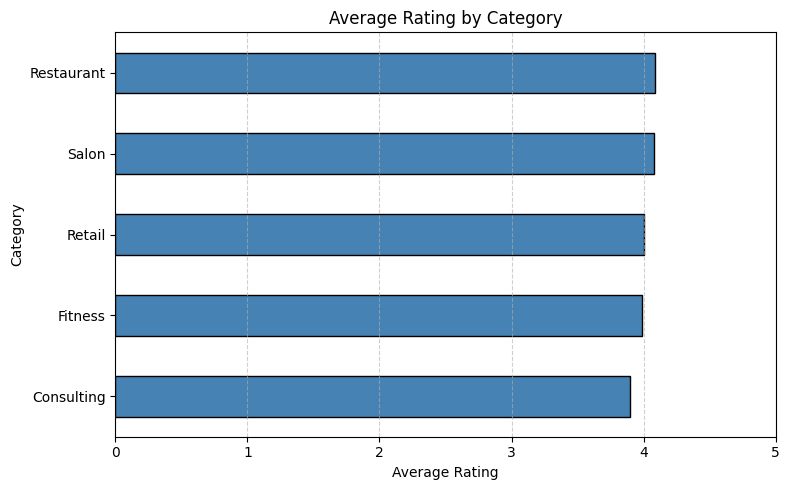

In [56]:
avg_ratings = df.groupby("Category")["Rating"].mean().sort_values(ascending=True)


plt.figure(figsize=(8, 5))
avg_ratings.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5) 
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Newsletter Adoption by Business Category

**Objective:**  
Evaluate customer engagement and communication preferences by examining the distribution of newsletter subscriptions across different industry segments.

**Analysis Performed:**  
* **Cross-Tabulation:** Generated a two-way frequency contingency table using `pd.crosstab()` to compute the breakdown of binary newsletter participation (`Yes` vs. `No`) segmented across each business `Category`.

In [28]:
pd.crosstab(df["Category"], df["Newsletter"])

Newsletter,No,Yes
Category,,
Consulting,5,1
Fitness,4,4
Restaurant,3,3
Retail,2,2
Salon,4,6


## Geographic Distribution by Business Category

**Objective:**  
Analyze the regional density and market presence of different industry verticals across various municipal locations.

**Analysis Performed:**  
* **Cross-Tabulation:** Built a two-dimensional frequency distribution table using `pd.crosstab()` to quantify business sector concentrations (`Category`) within each target market (`City`).

In [29]:
pd.crosstab(df["City"], df["Category"])

Category,Consulting,Fitness,Restaurant,Retail,Salon
City,,,,,
Austin,3,2,1,2,2
Boise,0,1,0,1,1
Denver,0,0,1,0,2
Nashville,1,1,1,0,2
Portland,1,1,0,0,1
Raleigh,1,3,3,1,2


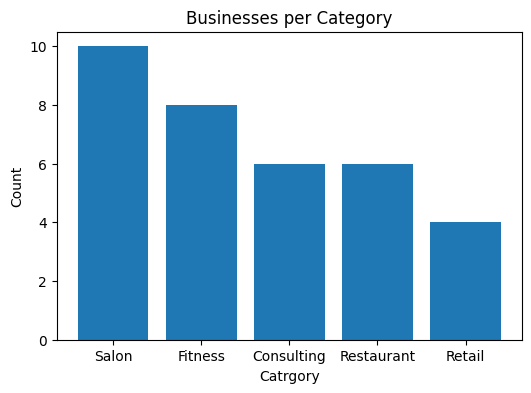

In [52]:
category_count = df["Category"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(category_count.index, category_count.values)
plt.title('Businesses per Category')
plt.xlabel('Catrgory')
plt.ylabel('Count')
plt.show()

## Graph with rating

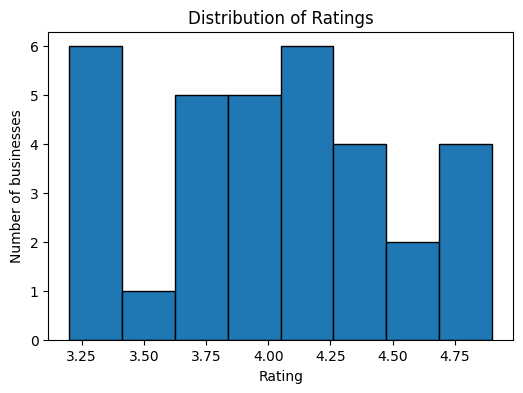

In [54]:
plt.figure(figsize=(6,4))
plt.hist(df["Rating"].dropna(), bins=8, edgecolor= 'black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of businesses')
plt.show()

# Printing Businesses in Cities by Rating.

## 1.Austin

In [35]:
df[df["City"] == "Austin"].sort_values(by="Rating", ascending=False)

,BusinessID,BusinessName,Category,City,Email,Website,YearsInBusiness,Rating,NumEmployees,SignupDate,Newsletter,Notes,NeedsReview
10,B011,Northside Fitness,Fitness,Austin,contact@northside.com,https://www.northside.com,3.0,4.6,38.0,2023-06-11,No,NaN,NaN
12,B013,Willow Restaurant,Restaurant,Austin,contact@willow.com,https://www.willow.com,10.0,4.4,NaN,2023-05-23,No,NaN,NaN
9,B010,Clover Consulting,Retail,Austin,contact@clover.com,https://www.clover.com,4.0,4.1,12.0,2023-06-05,No,NaN,NaN
2,B003,Sunset Retail,Retail,Austin,contact@sunset.com,https://www.sunset.com,18.0,4.0,38.0,2023-02-08,Yes,NaN,NaN
13,B014,Copper Hill Salon,Salon,Austin,contact@copperhill.com,https://www.copperhill.com,15.0,3.8,9.0,2023-08-02,Yes,NaN,NaN
26,B027,Cascade Consulting,Consulting,Austin,contact@cascade.com,https://www.cascade.com,17.0,3.7,7.0,2023-12-28,No,NaN,NaN
1,B002,Blue Oak Consulting,Consulting,Austin,contact@blueoak.com,https://www.blueoak.com,17.0,3.6,7.0,2023-07-14,Yes,NaN,NaN
31,B032,Ember Salon,Salon,Austin,NaN,https://www.ember.com,8.0,3.4,32.0,2023-04-11,Yes,NaN,True
20,B021,Foxglove Fitness,Fitness,Austin,contact@foxglove.com,NaN,7.0,3.3,15.0,2023-08-06,Yes,NaN,NaN
6,B007,Silver Line Consulting,Consulting,Austin,contact@silverline.com,https://www.silverline.com,20.0,NaN,36.0,2023-07-25,No,NaN,NaN


In [34]:
df[df["City"] == "Austin"].sort_values(by="Rating", ascending=False).to_csv("Austin_Business_sorted_by_rating.csv", index=False)

## 2.Boise

In [38]:
df[df["City"] == "Boise"].sort_values(by="Rating", ascending=False)

,BusinessID,BusinessName,Category,City,Email,Website,YearsInBusiness,Rating,NumEmployees,SignupDate,Newsletter,Notes,NeedsReview
16,B017,Amber Salon,Salon,Boise,contact@amber.com,https://www.amber.com,13.0,4.9,11.0,2023-02-06,Yes,NaN,NaN
19,B020,Lantern Fitness,Fitness,Boise,contact@lantern.com,https://www.lantern.com,18.0,3.9,27.0,2023-07-04,Yes,NaN,NaN
17,B018,Pine Grove Retail,Retail,Boise,sara.k@,https://www.pinegrove.com,8.0,3.2,39.0,2023-03-09,No,NaN,True


**In `B018`, The email needs to updated, so an updated note was added.**

In [40]:
df["Notes"] = df["Notes"].astype(object)
df.loc[df["BusinessID"] == "B018", "Notes"] = "Review for email"

In [51]:
df[df["City"] == "Boise"].sort_values(by="Rating", ascending=False).to_csv("Boise_Business_sorted_by_rating.csv", index=False)

## 3.Denver

In [50]:
df[df["City"] == "Denver"].sort_values(by="Rating", ascending=False).to_csv("Denver_Business_sorted_by_rating.csv", index=False)

## 4.Nashville

In [49]:
df[df["City"] == "Nashville"].sort_values(by="Rating", ascending=False).to_csv("Nashville_Business_sorted_by_rating.csv", index=False)

## 5.Portland

In [48]:
df[df["City"] == "Portland"].sort_values(by="Rating", ascending=False).to_csv("Portland_Business_sorted_by_rating.csv", index=False)

## 6.Raleigh

In [47]:
df[df["City"] == "Raleigh"].sort_values(by="Rating", ascending=False).to_csv("Raleigh_Business_sorted_by_rating.csv", index=False)